In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from zipfile import ZipFile

# =============================================================================
# 1. パス設定（出力先をCorr_1000直下に変更）
# =============================================================================
# ベースとなる作業ディレクトリ
BASE_WORKING_DIR = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/after_20251225/Corr_1000"

# 重要度データの元パス (10モデル分)
IMPORTANCE_BASE_PATH = os.path.join(BASE_WORKING_DIR, "results")

# Rawデータのパス
RAW_DATA_PATH = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/20251216_for_making_collect_data_nm_baseall_OHFP_csv/rebuilt_merged_data/"

# 出力フォルダ設定
OUTPUT_DIR_NAME = "Feature_Importance_Impact_Analysis_Results"
OUTPUT_DIR = os.path.join(BASE_WORKING_DIR, OUTPUT_DIR_NAME)
DIR_PLAN_A = os.path.join(OUTPUT_DIR, "PlanA_Directional")
DIR_PLAN_B = os.path.join(OUTPUT_DIR, "PlanB_SignLabeled")

for d in [DIR_PLAN_A, DIR_PLAN_B]:
    os.makedirs(d, exist_ok=True)

# =============================================================================
# 2. モデル構成とデータ対応の定義
# =============================================================================
MODEL_NAMES = ["MLP", "PPR", "GPR_Radial", "SVM_Linear", "SVM_Radial", "gcvEarth", "kNN", "GPR_Linear", "RandomForest", "PLS"]

best_model_configs = {
    ("PCE", "補完"):   ("SVM_Radial", "m_all_OH_rebuilt.csv"),
    ("PCE", "未補完"): ("RandomForest", "n_base_OH_rebuilt.csv"),
    ("Jsc", "補完"):   ("GPR_Linear", "m_all_OH_rebuilt.csv"),
    ("Jsc", "未補完"): ("SVM_Radial", "n_base_OH_rebuilt.csv"),
    ("Voc", "補完"):   ("RandomForest", "m_base_FP_rebuilt.csv"),
    ("Voc", "未補完"): ("SVM_Radial", "n_base_FP_rebuilt.csv"),
    ("FF", "補完"):    ("kNN", "m_all_FP_rebuilt.csv"),
    ("FF", "未補完"):  ("kNN", "n_all_FP_rebuilt.csv")
}

# =============================================================================
# 3. データ読み込みと可視化ロジック (統合)
# =============================================================================
print("--- データのロード中 ---")
all_data_list = []
for model in MODEL_NAMES:
    file_path = os.path.join(IMPORTANCE_BASE_PATH, f"Corr_1000_{model}", f"all_importance_{model}_VIP.csv")
    if os.path.exists(file_path):
        tmp_df = pd.read_csv(file_path)
        tmp_df['Model'] = model
        tmp_df['Imputation_Type'] = tmp_df['File'].apply(lambda x: '補完' if x.startswith('m_') else '未補完')
        all_data_list.append(tmp_df)

if not all_data_list:
    raise FileNotFoundError("指定されたパスに重要度CSVが見つかりませんでした。")

master_df = pd.concat(all_data_list, ignore_index=True)

def get_rank_color(cmap_name, rank, total=15):
    cmap = plt.get_cmap(cmap_name)
    val = 0.85 - (rank / total) * 0.55
    return cmap(val)

def get_impact_info(df_raw, target, feature):
    if df_raw is None or feature not in df_raw.columns:
        return 0, "Neutral"
    valid_data = df_raw[[feature, target]].dropna()
    if len(valid_data) < 2: return 0, "Neutral"
    feat_vals, tgt_vals = valid_data[feature], valid_data[target]
    val = tgt_vals[feat_vals == 1].mean() - tgt_vals[feat_vals == 0].mean() if set(feat_vals.unique()).issubset({0, 1}) else feat_vals.corr(tgt_vals)
    return val, ("Positive" if val > 0.0001 else "Negative" if val < -0.0001 else "Neutral")

raw_data_cache = {}
targets = ["PCE", "Jsc", "Voc", "FF"]

for target in targets:
    def extract_best(itype):
        conf = best_model_configs.get((target, itype))
        if not conf: return pd.DataFrame()
        m_name, r_file = conf
        sub = master_df[(master_df['Target'] == target) & (master_df['Imputation_Type'] == itype) & (master_df['Model'] == m_name)].copy()
        if sub.empty: return sub
        sub['Norm_Imp'] = sub['Importance'] / sub['Importance'].max()
        sub = sub.sort_values('Norm_Imp', ascending=False).head(15)
        sub['Rank'] = range(len(sub))
        if (target, itype) not in raw_data_cache:
            f = os.path.join(RAW_DATA_PATH, r_file)
            if os.path.exists(f): raw_data_cache[(target, itype)] = pd.read_csv(f)
        return sub

    df_imp, df_non = extract_best('補完'), extract_best('未補完')
    ordered = df_imp['Feature'].tolist() + [f for f in df_non['Feature'].tolist() if f not in df_imp['Feature'].tolist()]
    display_features = ordered[::-1]

    for plan in ['A', 'B']:
        fig, ax = plt.subplots(figsize=(11, len(display_features) * 0.4 + 1.2))
        y_pos = np.arange(len(display_features))
        height = 0.35
        for i, feat in enumerate(display_features):
            for s_df, itype, cmap, offset in [(df_imp, '補完', 'Reds', height/2), (df_non, '未補完', 'Blues', -height/2)]:
                if not s_df.empty and feat in s_df['Feature'].values:
                    d = s_df[s_df['Feature'] == feat].iloc[0]
                    _, trend = get_impact_info(raw_data_cache.get((target, itype)), target, feat)
                    if plan == 'A':
                        ax.barh(i + offset, d['Norm_Imp'] * (-1 if trend == "Negative" else 1), height=height, color=get_rank_color(cmap, d['Rank']))
                    else:
                        ax.barh(i + offset, d['Norm_Imp'], height=height, color=get_rank_color(cmap, d['Rank']))
                        ax.text(d['Norm_Imp'] + 0.01, i + offset, "+" if trend == "Positive" else "-" if trend == "Negative" else "", va='center', fontsize=14, fontweight='bold')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(display_features)
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.set_title(f"Target: {target} | Imp:{best_model_configs[(target,'補完')][0]} vs Non:{best_model_configs[(target,'未補完')][0]}", loc='left')
        save_name = f"{target}_PlanA.png" if plan == 'A' else f"{target}_PlanB.png"
        plt.tight_layout()
        plt.savefig(os.path.join(DIR_PLAN_A if plan == 'A' else DIR_PLAN_B, save_name), dpi=300)
        plt.close()

# =============================================================================
# 4. ZIP圧縮と完了報告
# =============================================================================
zip_path = os.path.join(BASE_WORKING_DIR, f"{OUTPUT_DIR_NAME}.zip")
with ZipFile(zip_path, 'w') as zipf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            zipf.write(os.path.join(root, file), arcname=os.path.join(os.path.relpath(root, OUTPUT_DIR), file))

print(f"\n--- 処理完了 ---")
print(f"結果フォルダ: {OUTPUT_DIR}")
print(f"ZIPファイル: {zip_path}")

--- データのロード中 ---

--- 処理完了 ---
結果フォルダ: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/after_20251225/Corr_1000/Feature_Importance_Impact_Analysis_Results
ZIPファイル: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/after_20251225/Corr_1000/Feature_Importance_Impact_Analysis_Results.zip


In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from zipfile import ZipFile

# =============================================================================
# 1. パスと設定
# =============================================================================
BASE_WORKING_DIR = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/after_20251225/Corr_1000"
IMPORTANCE_BASE_PATH = os.path.join(BASE_WORKING_DIR, "results")
RAW_DATA_PATH = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/20251216_for_making_collect_data_nm_baseall_OHFP_csv/rebuilt_merged_data/"

OUTPUT_DIR_NAME = "Feature_Importance_Impact_Analysis_Results"
OUTPUT_DIR = os.path.join(BASE_WORKING_DIR, OUTPUT_DIR_NAME)
for d in ["PlanA_Directional", "PlanB_SignLabeled"]:
    os.makedirs(os.path.join(OUTPUT_DIR, d), exist_ok=True)

# 抽出したいモデルのキーワード（大文字小文字を無視して照合します）
best_model_configs = {
    ("PCEmax", "補完"):   ("svm", "radial", "m_all_OH_rebuilt.csv"), # SVM かつ Radial を含むもの
    ("PCEmax", "未補完"): ("random", "forest", "n_base_OH_rebuilt.csv"),
    ("Jsc", "補完"):   ("gpr", "linear", "m_all_OH_rebuilt.csv"),
    ("Jsc", "未補完"): ("svm", "radial", "n_base_OH_rebuilt.csv"),
    ("Voc", "補完"):   ("random", "forest", "m_base_FP_rebuilt.csv"),
    ("Voc", "未補完"): ("svm", "radial", "n_base_FP_rebuilt.csv"),
    ("FF", "補完"):    ("knn", "", "m_all_FP_rebuilt.csv"),
    ("FF", "未補完"):  ("knn", "", "n_all_FP_rebuilt.csv")
}

# =============================================================================
# 2. データの自動収集（部分一致検索）
# =============================================================================
all_data_list = []
if os.path.exists(IMPORTANCE_BASE_PATH):
    for d in os.listdir(IMPORTANCE_BASE_PATH):
        if not d.startswith("Corr_1000_"): continue
        
        # フォルダ内からCSVを探す
        dir_path = os.path.join(IMPORTANCE_BASE_PATH, d)
        csv_files = [f for f in os.listdir(dir_path) if f.endswith(".csv") and "importance" in f.lower()]
        
        for f in csv_files:
            tmp_df = pd.read_csv(os.path.join(dir_path, f))
            # フォルダ名をタグとして保持
            tmp_df['Folder_Name'] = d.lower() 
            tmp_df['Imputation_Type'] = tmp_df['File'].apply(lambda x: '補完' if str(x).startswith('m_') else '未補完')
            all_data_list.append(tmp_df)

if not all_data_list:
    print("重要度データが見つかりませんでした。")
    exit()

master_df = pd.concat(all_data_list, ignore_index=True)

# =============================================================================
# 3. 描画
# =============================================================================
def get_rank_color(cmap_name, rank, total=15):
    cmap = plt.get_cmap(cmap_name)
    return cmap(0.85 - (rank / total) * 0.55)

def get_impact_info(df_raw, target, feature):
    if df_raw is None or feature not in df_raw.columns: return 0, "Neutral"
    valid = df_raw[[feature, target]].dropna()
    if len(valid) < 2: return 0, "Neutral"
    val = valid[target][valid[feature]==1].mean() - valid[target][valid[feature]==0].mean() if set(valid[feature].unique()).issubset({0,1}) else valid[feature].corr(valid[target])
    return val, ("Positive" if val > 0.0001 else "Negative" if val < -0.0001 else "Neutral")

raw_data_cache = {}
targets = ["PCEmax", "Jsc", "Voc", "FF"]

for target in targets:
    def get_df(itype):
        conf = best_model_configs.get((target, itype))
        if not conf: return pd.DataFrame()
        key1, key2, r_file = conf
        
        # キーワード(key1, key2)がフォルダ名に含まれるものを抽出
        sub = master_df[(master_df['Target'] == target) & 
                        (master_df['Imputation_Type'] == itype) & 
                        (master_df['Folder_Name'].str.contains(key1.lower())) & 
                        (master_df['Folder_Name'].str.contains(key2.lower()))].copy()
        
        if sub.empty: return sub
        sub['Norm_Imp'] = sub['Importance'] / sub['Importance'].max()
        sub = sub.sort_values('Norm_Imp', ascending=False).head(15)
        sub['Rank'] = range(len(sub))
        if (target, itype) not in raw_data_cache:
            f = os.path.join(RAW_DATA_PATH, r_file)
            if os.path.exists(f): raw_data_cache[(target, itype)] = pd.read_csv(f)
        return sub

    df_imp, df_non = get_df('補完'), get_df('未補完')
    if df_imp.empty and df_non.empty:
        print(f"No match for {target}")
        continue

    ordered = df_imp['Feature'].tolist() + [f for f in df_non['Feature'].tolist() if f not in df_imp['Feature'].tolist()]
    display_features = ordered[::-1]

    for plan in ['A', 'B']:
        fig, ax = plt.subplots(figsize=(11, len(display_features) * 0.4 + 1.2))
        for i, feat in enumerate(display_features):
            for s_df, itype, cmap, offset in [(df_imp, '補完', 'Reds', 0.18), (df_non, '未補完', 'Blues', -0.18)]:
                if not s_df.empty and feat in s_df['Feature'].values:
                    d = s_df[s_df['Feature'] == feat].iloc[0]
                    _, trend = get_impact_info(raw_data_cache.get((target, itype)), target, feat)
                    if plan == 'A':
                        val = d['Norm_Imp'] * (-1 if trend == "Negative" else 1)
                        ax.barh(i + offset, val, height=0.35, color=get_rank_color(cmap, d['Rank']))
                    else:
                        ax.barh(i + offset, d['Norm_Imp'], height=0.35, color=get_rank_color(cmap, d['Rank']))
                        ax.text(d['Norm_Imp'] + 0.01, i + offset, "+" if trend == "Positive" else "-" if trend == "Negative" else "", va='center', fontsize=12)
        
        ax.set_yticks(np.arange(len(display_features)))
        ax.set_yticklabels(display_features)
        ax.set_title(f"Target: {target}", loc='left')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "PlanA_Directional" if plan=='A' else "PlanB_SignLabeled", f"{target}_{plan}.png"), dpi=300)
        plt.close()

# =============================================================================
# 4. ZIP
# =============================================================================
zip_path = os.path.join(BASE_WORKING_DIR, f"{OUTPUT_DIR_NAME}.zip")
with ZipFile(zip_path, 'w') as zipf:
    for root, _, files in os.walk(OUTPUT_DIR):
        for f in files: zipf.write(os.path.join(root, f), arcname=os.path.join(os.path.relpath(root, OUTPUT_DIR), f))

print(f"完了: {zip_path}")

完了: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/after_20251225/Corr_1000/Feature_Importance_Impact_Analysis_Results.zip


KeyboardInterrupt: 

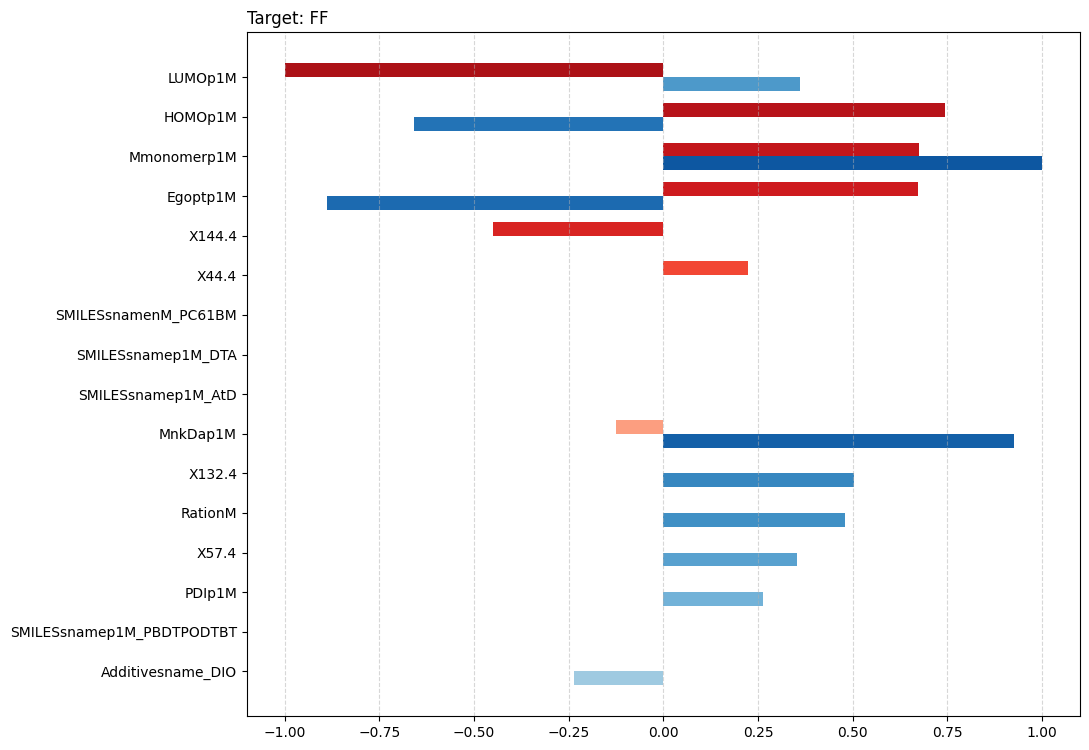

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from zipfile import ZipFile

# =============================================================================
# 1. パスと設定
# =============================================================================
BASE_WORKING_DIR = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/after_20251225/Corr_1000"
IMPORTANCE_BASE_PATH = os.path.join(BASE_WORKING_DIR, "results")
RAW_DATA_PATH = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/20251216_for_making_collect_data_nm_baseall_OHFP_csv/rebuilt_merged_data/"

OUTPUT_DIR_NAME = "Feature_Importance_Impact_Analysis_Results"
OUTPUT_DIR = os.path.join(BASE_WORKING_DIR, OUTPUT_DIR_NAME)
CSV_DIR = os.path.join(OUTPUT_DIR, "CSV_Summary") # CSV保存用フォルダ
for d in [os.path.join(OUTPUT_DIR, "PlanA_Directional"), 
          os.path.join(OUTPUT_DIR, "PlanB_SignLabeled"), CSV_DIR]:
    os.makedirs(d, exist_ok=True)

best_model_configs = {
    ("PCEmax", "補完"):   ("svm", "radial", "m_all_OH_rebuilt.csv"),
    ("PCEmax", "未補完"): ("random", "forest", "n_base_OH_rebuilt.csv"),
    ("Jsc", "補完"):   ("gpr", "linear", "m_all_OH_rebuilt.csv"),
    ("Jsc", "未補完"): ("svm", "radial", "n_base_OH_rebuilt.csv"),
    ("Voc", "補完"):   ("random", "forest", "m_base_FP_rebuilt.csv"),
    ("Voc", "未補完"): ("svm", "radial", "n_base_FP_rebuilt.csv"),
    ("FF", "補完"):    ("knn", "", "m_all_FP_rebuilt.csv"),
    ("FF", "未補完"):  ("knn", "", "n_all_FP_rebuilt.csv")
}

# =============================================================================
# 2. データ収集
# =============================================================================
all_data_list = []
if os.path.exists(IMPORTANCE_BASE_PATH):
    for d in os.listdir(IMPORTANCE_BASE_PATH):
        if not d.startswith("Corr_1000_"): continue
        dir_path = os.path.join(IMPORTANCE_BASE_PATH, d)
        csv_files = [f for f in os.listdir(dir_path) if f.endswith(".csv") and "importance" in f.lower()]
        for f in csv_files:
            tmp_df = pd.read_csv(os.path.join(dir_path, f))
            tmp_df['Folder_Name'] = d.lower() 
            tmp_df['Imputation_Type'] = tmp_df['File'].apply(lambda x: '補完' if str(x).startswith('m_') else '未補完')
            all_data_list.append(tmp_df)

master_df = pd.concat(all_data_list, ignore_index=True)

# =============================================================================
# 3. 補助関数
# =============================================================================
def get_rank_color(cmap_name, rank, total=15):
    cmap = plt.get_cmap(cmap_name)
    return cmap(0.85 - (rank / total) * 0.55)

def get_impact_info(df_raw, target, feature):
    if df_raw is None or feature not in df_raw.columns: return 0, "Neutral"
    valid = df_raw[[feature, target]].dropna()
    if len(valid) < 2: return 0, "Neutral"
    v = valid[target][valid[feature]==1].mean() - valid[target][valid[feature]==0].mean() if set(valid[feature].unique()).issubset({0,1}) else valid[feature].corr(valid[target])
    return v, ("Positive" if v > 0.0001 else "Negative" if v < -0.0001 else "Neutral")

# =============================================================================
# 4. メイン処理：CSV生成と可視化
# =============================================================================
raw_data_cache = {}
targets = ["PCEmax", "Jsc", "Voc", "FF"]

for target in targets:
    dfs = {} # 補完/未補完それぞれのデータを格納
    for itype in ['補完', '未補完']:
        conf = best_model_configs.get((target, itype))
        if not conf: continue
        key1, key2, r_file = conf
        
        # モデル一致データの抽出
        sub = master_df[(master_df['Target'] == target) & 
                        (master_df['Imputation_Type'] == itype) & 
                        (master_df['Folder_Name'].str.contains(key1.lower())) & 
                        (master_df['Folder_Name'].str.contains(key2.lower()))].copy()
        
        if sub.empty: continue

        # Rawデータ読み込みとImpact(相関/符号)計算
        if (target, itype) not in raw_data_cache:
            fpath = os.path.join(RAW_DATA_PATH, r_file)
            if os.path.exists(fpath): raw_data_cache[(target, itype)] = pd.read_csv(fpath)

        raw_df = raw_data_cache.get((target, itype))
        sub['Impact_Value'] = sub['Feature'].apply(lambda x: get_impact_info(raw_df, target, x)[0])
        sub['Trend'] = sub['Feature'].apply(lambda x: get_impact_info(raw_df, target, x)[1])
        
        # 重要度順にソートしてRank付与
        sub = sub.sort_values('Importance', ascending=False)
        sub['Rank'] = range(1, len(sub) + 1)
        sub['Norm_Imp'] = sub['Importance'] / sub['Importance'].max()
        sub['Directional_Imp'] = sub['Norm_Imp'] * sub['Trend'].map({'Positive':1, 'Negative':-1, 'Neutral':0})

        # --- CSV保存 (全件 / Top15) ---
        base_name = f"{target}_{itype}"
        sub.to_csv(os.path.join(CSV_DIR, f"{base_name}_All_Features.csv"), index=False)
        sub.head(15).to_csv(os.path.join(CSV_DIR, f"{base_name}_Top15.csv"), index=False)
        
        dfs[itype] = sub.head(15)

    # --- 描画用データ準備 (重複排除) ---
    if not dfs: continue
    df_imp = dfs.get('補完', pd.DataFrame())
    df_non = dfs.get('未補完', pd.DataFrame())
    
    # 集合を使って重複のない特徴量リストを作成
    all_feats = []
    seen = set()
    for f in list(df_imp['Feature']) + list(df_non['Feature']):
        if f not in seen:
            all_feats.append(f)
            seen.add(f)
    display_features = all_feats[::-1]

    # --- グラフ描画 ---
    for plan in ['A', 'B']:
        fig, ax = plt.subplots(figsize=(11, len(display_features) * 0.4 + 1.2))
        y_pos = np.arange(len(display_features))
        height = 0.35
        
        for i, feature in enumerate(display_features):
            for sub_df, itype, cmap, offset in [(df_imp, '補完', 'Reds', height/2), (df_non, '未補完', 'Blues', -height/2)]:
                if not sub_df.empty and feature in sub_df['Feature'].values:
                    d = sub_df[sub_df['Feature'] == feature].iloc[0]
                    if plan == 'A':
                        ax.barh(i + offset, d['Directional_Imp'], height=height, color=get_rank_color(cmap, d['Rank']-1))
                    else:
                        ax.barh(i + offset, d['Norm_Imp'], height=height, color=get_rank_color(cmap, d['Rank']-1))
                        sign = "+" if d['Trend'] == "Positive" else ("-" if d['Trend'] == "Negative" else "")
                        ax.text(d['Norm_Imp'] + 0.01, i + offset, sign, va='center', fontsize=16, fontweight='bold')

        ax.set_yticks(y_pos)
        ax.set_yticklabels(display_features)
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.set_title(f"Target: {target}", loc='left')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "PlanA_Directional" if plan=='A' else "PlanB_SignLabeled", f"{target}_{plan}.png"), dpi=300)
        plt.close()

# =============================================================================
# 5. ZIP圧縮
# =============================================================================
zip_path = os.path.join(BASE_WORKING_DIR, f"{OUTPUT_DIR_NAME}.zip")
with ZipFile(zip_path, 'w') as zipf:
    for root, _, files in os.walk(OUTPUT_DIR):
        for f in files: zipf.write(os.path.join(root, f), arcname=os.path.join(os.path.relpath(root, OUTPUT_DIR), f))

print(f"\n--- 処理完了 ---")
print(f"CSV(16ファイル)およびグラフを生成しました。")
print(f"ZIP: {zip_path}")

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from zipfile import ZipFile

# =============================================================================
# 1. パスと設定
# =============================================================================
BASE_WORKING_DIR = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/after_20251225/Corr_1000"
IMPORTANCE_BASE_PATH = os.path.join(BASE_WORKING_DIR, "results")
RAW_DATA_PATH = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/20251216_for_making_collect_data_nm_baseall_OHFP_csv/rebuilt_merged_data/"

OUTPUT_DIR_NAME = "Feature_Importance_Impact_Analysis_Results"
OUTPUT_DIR = os.path.join(BASE_WORKING_DIR, OUTPUT_DIR_NAME)
CSV_DIR = os.path.join(OUTPUT_DIR, "CSV_Summary")
for d in [os.path.join(OUTPUT_DIR, "PlanA_Directional"), 
          os.path.join(OUTPUT_DIR, "PlanB_SignLabeled"), CSV_DIR]:
    os.makedirs(d, exist_ok=True)

# 厳密なファイル名とモデルフォルダのキーワードを定義
# (ターゲット, 補完タイプ): (フォルダ検索語, 検索語2, 対応するRawデータ, 重要度CSV内のFile列の期待値)
best_model_configs = {
    ("PCEmax", "補完"):   ("svm", "radial", "m_all_OH_rebuilt.csv", "m_all_OH_rebuilt.csv"),
    ("PCEmax", "未補完"): ("random", "forest", "n_base_OH_rebuilt.csv", "n_base_OH_rebuilt.csv"),
    ("Jsc", "補完"):   ("gpr", "linear", "m_all_OH_rebuilt.csv", "m_all_OH_rebuilt.csv"),
    ("Jsc", "未補完"): ("svm", "radial", "n_base_OH_rebuilt.csv", "n_base_OH_rebuilt.csv"),
    ("Voc", "補完"):   ("random", "forest", "m_base_FP_rebuilt.csv", "m_base_FP_rebuilt.csv"),
    ("Voc", "未補完"): ("svm", "radial", "n_base_FP_rebuilt.csv", "n_base_FP_rebuilt.csv"),
    ("FF", "補完"):    ("knn", "", "m_all_FP_rebuilt.csv", "m_all_FP_rebuilt.csv"),
    ("FF", "未補完"):  ("knn", "", "n_all_FP_rebuilt.csv", "n_all_FP_rebuilt.csv")
}

# =============================================================================
# 2. データの収集と厳密なフィルタリング
# =============================================================================
all_data_list = []
if os.path.exists(IMPORTANCE_BASE_PATH):
    for d in os.listdir(IMPORTANCE_BASE_PATH):
        if not d.startswith("Corr_1000_"): continue
        dir_path = os.path.join(IMPORTANCE_BASE_PATH, d)
        
        # フォルダ内の重要度CSVをスキャン
        csv_files = [f for f in os.listdir(dir_path) if f.endswith(".csv") and "importance" in f.lower()]
        for f in csv_files:
            tmp_df = pd.read_csv(os.path.join(dir_path, f))
            tmp_df['Folder_Name'] = d.lower()
            # File列に基づいて、その行が補完か未補完かを厳密に判定
            tmp_df['Imputation_Type'] = tmp_df['File'].apply(lambda x: '補完' if str(x).startswith('m_') else '未補完')
            all_data_list.append(tmp_df)

master_df = pd.concat(all_data_list, ignore_index=True)

# =============================================================================
# 3. 解析・CSV・可視化
# =============================================================================
def get_rank_color(cmap_name, rank, total=15):
    return plt.get_cmap(cmap_name)(0.85 - (rank / total) * 0.55)

def get_impact_info(df_raw, target, feature):
    if df_raw is None or feature not in df_raw.columns: return 0, "Neutral"
    valid = df_raw[[feature, target]].dropna()
    if len(valid) < 2: return 0, "Neutral"
    v = valid[target][valid[feature]==1].mean() - valid[target][valid[feature]==0].mean() if set(valid[feature].unique()).issubset({0,1}) else valid[feature].corr(valid[target])
    return v, ("Positive" if v > 0.0001 else "Negative" if v < -0.0001 else "Neutral")

raw_data_cache = {}
targets = ["PCEmax", "Jsc", "Voc", "FF"]

for target in targets:
    dfs = {}
    for itype in ['補完', '未補完']:
        conf = best_model_configs.get((target, itype))
        if not conf: continue
        k1, k2, r_file, f_col = conf # f_col: CSV内のFile列と一致すべき名前
        
        # フォルダ名とFile列の両方で厳密にフィルタリング
        sub = master_df[(master_df['Target'] == target) & 
                        (master_df['Folder_Name'].str.contains(k1.lower())) & 
                        (master_df['Folder_Name'].str.contains(k2.lower())) & 
                        (master_df['File'] == f_col)].copy()
        
        if sub.empty: continue

        # Rawデータの取得
        if (target, itype) not in raw_data_cache:
            fpath = os.path.join(RAW_DATA_PATH, r_file)
            if os.path.exists(fpath): raw_data_cache[(target, itype)] = pd.read_csv(fpath)
        
        raw_df = raw_data_cache.get((target, itype))
        sub['Impact_Value'] = sub['Feature'].apply(lambda x: get_impact_info(raw_df, target, x)[0])
        sub['Trend'] = sub['Feature'].apply(lambda x: get_impact_info(raw_df, target, x)[1])
        
        sub = sub.sort_values('Importance', ascending=False)
        sub['Rank'] = range(1, len(sub) + 1)
        sub['Norm_Imp'] = sub['Importance'] / sub['Importance'].max()
        sub['Directional_Imp'] = sub['Norm_Imp'] * sub['Trend'].map({'Positive':1, 'Negative':-1, 'Neutral':0})

        # CSV出力
        sub.to_csv(os.path.join(CSV_DIR, f"{target}_{itype}_All.csv"), index=False)
        sub.head(15).to_csv(os.path.join(CSV_DIR, f"{target}_{itype}_Top15.csv"), index=False)
        dfs[itype] = sub.head(15)

    # 描画 (重複排除)
    if not dfs: continue
    all_feats = []
    seen = set()
    for f in list(dfs.get('補完', pd.DataFrame())['Feature']) + list(dfs.get('未補完', pd.DataFrame())['Feature']):
        if f not in seen:
            all_feats.append(f)
            seen.add(f)
    display_features = all_feats[::-1]

    for plan in ['A', 'B']:
        fig, ax = plt.subplots(figsize=(11, len(display_features) * 0.4 + 1.2))
        height = 0.35
        for i, feat in enumerate(display_features):
            for itype, cmap, offset in [('補完', 'Reds', height/2), ('未補完', 'Blues', -height/2)]:
                s_df = dfs.get(itype, pd.DataFrame())
                if not s_df.empty and feat in s_df['Feature'].values:
                    d = s_df[s_df['Feature'] == feat].iloc[0]
                    if plan == 'A':
                        ax.barh(i + offset, d['Directional_Imp'], height=height, color=get_rank_color(cmap, d['Rank']-1))
                    else:
                        ax.barh(i + offset, d['Norm_Imp'], height=height, color=get_rank_color(cmap, d['Rank']-1))
                        sign = "+" if d['Trend'] == "Positive" else "-" if d['Trend'] == "Negative" else ""
                        ax.text(d['Norm_Imp'] + 0.01, i + offset, sign, va='center', fontsize=16, fontweight='bold')
        ax.set_yticks(np.arange(len(display_features)))
        ax.set_yticklabels(display_features)
        ax.set_title(f"Target: {target}", loc='left')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "PlanA_Directional" if plan=='A' else "PlanB_SignLabeled", f"{target}_{plan}.png"), dpi=300)
        plt.close()

# ZIP圧縮
zip_path = os.path.join(BASE_WORKING_DIR, f"{OUTPUT_DIR_NAME}.zip")
with ZipFile(zip_path, 'w') as zipf:
    for root, _, files in os.walk(OUTPUT_DIR):
        for f in files: zipf.write(os.path.join(root, f), arcname=os.path.join(os.path.relpath(root, OUTPUT_DIR), f))

print(f"完了: {zip_path}")

In [11]:
import os
import pandas as pd

# =============================================================================
# 1. パスと設定
# =============================================================================
BASE_WORKING_DIR = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/after_20251225/Corr_1000"
IMPORTANCE_BASE_PATH = os.path.join(BASE_WORKING_DIR, "results")

# ターゲット、補完タイプ、フォルダキーワード、そして「厳密に一致すべきFile列名」
best_model_configs = {
    ("PCEmax", "補完"):   ("svm", "radial", "m_all_OH_rebuilt.csv"),
    ("PCEmax", "未補完"): ("random", "forest", "n_base_OH_rebuilt.csv"),
    ("Jsc", "補完"):   ("gpr", "linear", "m_all_OH_rebuilt.csv"),
    ("Jsc", "未補完"): ("svm", "radial", "n_base_OH_rebuilt.csv"),
    ("Voc", "補完"):   ("random", "forest", "m_base_FP_rebuilt.csv"),
    ("Voc", "未補完"): ("svm", "radial", "n_base_FP_rebuilt.csv"),
    ("FF", "補完"):    ("knn", "", "m_all_FP_rebuilt.csv"),
    ("FF", "未補完"):  ("knn", "", "n_all_FP_rebuilt.csv")
}

# =============================================================================
# 2. データの収集
# =============================================================================
all_data_list = []
if os.path.exists(IMPORTANCE_BASE_PATH):
    for d in os.listdir(IMPORTANCE_BASE_PATH):
        if not d.startswith("Corr_1000_"): continue
        dir_path = os.path.join(IMPORTANCE_BASE_PATH, d)
        csv_files = [f for f in os.listdir(dir_path) if f.endswith(".csv") and "importance" in f.lower()]
        for f in csv_files:
            tmp_df = pd.read_csv(os.path.join(dir_path, f))
            tmp_df['Folder_Name'] = d.lower()
            all_data_list.append(tmp_df)

if not all_data_list:
    print("Error: No importance data found.")
    exit()

master_df = pd.concat(all_data_list, ignore_index=True)

# =============================================================================
# 3. 各モデルのTop 20を表示
# =============================================================================
print("="*90)
print(f"{'Target':<8} | {'Type':<4} | {'Model Folder':<25} | {'Source File (Filter)':<25}")
print("-"*90)

for (target, itype), (k1, k2, f_col) in best_model_configs.items():
    # フォルダ名キーワードと、File列の完全一致でフィルタリング
    sub = master_df[(master_df['Target'] == target) & 
                    (master_df['Folder_Name'].str.contains(k1.lower())) & 
                    (master_df['Folder_Name'].str.contains(k2.lower())) & 
                    (master_df['File'] == f_col)].copy()
    
    print(f"{target:<8} | {itype:<4} | キーワード: {k1}+{k2:<12} | Filter: {f_col}")
    
    if sub.empty:
        print("  [!] 条件に一致するデータが見つかりませんでした。")
    else:
        # 重要度でソートしてTop 20を抽出
        top20 = sub.sort_values('Importance', ascending=False).head(20)
        
        # コンソール表示用の整形
        lines = []
        for i, (idx, row) in enumerate(top20.iterrows(), 1):
            lines.append(f"{i:2}. {row['Feature']:<15} ({row['Importance']:7.4f})")
        
        # 5個ずつ横に並べて表示（見やすさのため）
        for j in range(0, len(lines), 4):
            print("    " + "  ".join(lines[j:j+4]))
            
    print("-"*90)

print("="*90)

Target   | Type | Model Folder              | Source File (Filter)     
------------------------------------------------------------------------------------------
PCEmax   | 補完   | キーワード: svm+radial       | Filter: m_all_OH_rebuilt.csv
     1. SMILESsnamep1M_PBDTFQT ( 0.0304)   2. SMILESsnamep1M_TzTzBTIDG ( 0.0280)   3. SMILESsnamep1M_PffBT4T2OD ( 0.0264)   4. SMILESsnamep1M_PNTz4T ( 0.0251)
     5. Lay5electronodes1_MoO3orV2O5 ( 0.0245)   6. SMILESsnamep1M_PPDT2FBT ( 0.0205)   7. SMILESsnamep1M_AtD ( 0.0193)   8. SMILESsnamep1M_BBTzBTIDG ( 0.0191)
     9. SMILESsnamep1M_PNOz4T ( 0.0177)  10. SMILESsnamep1M_TzTzalkylthiopheneBTIDG ( 0.0174)  11. SMILESsnamep1M_C6DPPBP ( 0.0169)  12. SMILESsnamep1M_PSEHTT ( 0.0160)
    13. SMILESsnamep1M_CPDTDTKP ( 0.0160)  14. Lay5electronodes1_MoO3 ( 0.0159)  15. SMILESsnamenM_PTBI2Tz ( 0.0152)  16. SMILESsnamep1M_C8DPPBP ( 0.0151)
    17. namessolvent1_DCM ( 0.0145)  18. SMILESsnamenM_DBFIEDOT ( 0.0145)  19. SMILESsnamenM_PCBM ( 0.0144)  20. SMILESsn